In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dicionario de dados

- ano: Ano de aplicação da avaliação estadual
- id_municipio: ID município de 7 dígitos
- id_escola: Máscara do códigoo da escola (códigos fictícios)
- id_aluno: Código do aluno
- caderno: Código do caderno atribuído ao aluno na prova de língua portuguesa
- serie: Ano escolar
- rede: Dependência administrativa da escola
- presenca: Indicador de presença na prova de língua portuguesa
- preenchimento_caderno: Indicador de preenchimento da prova de língua portuguesa
- alfabetizado: Indica se o aluno, mediante o resultado da avaliação estadual, é considerado alfabetizado
- proficiencia: Proficiência do aluno em língua portuguesa calculada na escala equalizada com o SAEB
- peso_aluno: Peso do aluno na prova de língua portuguesa
- mun_taxa_alfabetizacao: Percentual dos alunos avaliados no município que foram considerados, mediante o resultado da avaliação estadual, como alfabetizados
- mun_media_portugues: Média ponderada do município na avaliação estadual na disciplina Língua Portuguesa (LP) equalizada com o SAEB

In [ ]:
# Carregando tabelas

ANOS = [2023, 2024]
df = pd.concat([
    pd.read_parquet(f"../data/silver/integrado/year={ano}/dados.parquet")
    for ano in ANOS
], ignore_index=True)

(3355822, 14)


,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno,mun_taxa_alfabetizacao,mun_media_portugues
0,2023,3300704,60025977,33014516,1,2,Municipal,1,1,1,746.319800,0.310110,54.58,742.9705
1,2023,3121605,60021971,31008498,1,2,Municipal,1,1,1,772.288100,0.452510,59.54,748.5891
2,2023,3157807,60018571,31151092,1,2,Estadual,1,1,1,776.191000,0.545775,53.75,745.1835
3,2023,4204806,60035456,42032360,1,2,Municipal,1,1,1,764.075514,0.585886,48.56,731.6748
4,2023,4204806,60035456,42032357,1,2,Municipal,1,1,1,772.580780,0.585886,48.56,731.6748


In [6]:
print(f'tamanho do nosso dataset (Linhas, Colunas): {df.shape}')

tamanho do nosso dataset (Linhas, Colunas): (3355822, 14)


In [5]:
df.head()

,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno,mun_taxa_alfabetizacao,mun_media_portugues
0,2023,3300704,60025977,33014516,1,2,Municipal,1,1,1,746.319800,0.310110,54.58,742.9705
1,2023,3121605,60021971,31008498,1,2,Municipal,1,1,1,772.288100,0.452510,59.54,748.5891
2,2023,3157807,60018571,31151092,1,2,Estadual,1,1,1,776.191000,0.545775,53.75,745.1835
3,2023,4204806,60035456,42032360,1,2,Municipal,1,1,1,764.075514,0.585886,48.56,731.6748
4,2023,4204806,60035456,42032357,1,2,Municipal,1,1,1,772.580780,0.585886,48.56,731.6748


In [4]:
df.tail()

,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno,mun_taxa_alfabetizacao,mun_media_portugues
3355817,2024,4322400,60038978,43098836,9,2,Municipal,1,1,0,697.423980,2.00,47.30,735.1702
3355818,2024,2602902,60013156,26035176,9,2,Municipal,1,1,0,732.780000,2.38,50.72,737.7800
3355819,2024,4314902,60038096,43065853,9,2,Estadual,1,1,0,667.897123,2.40,31.30,718.9763
3355820,2024,3167202,60019847,31182116,9,2,Municipal,1,1,1,761.840000,2.43,60.35,747.0200
3355821,2024,5300108,60042409,53014042,9,2,Estadual,1,1,0,664.530000,2.61,59.13,743.0100


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3355822 entries, 0 to 3355821
Data columns (total 14 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   ano                     int64  
 1   id_municipio            int64  
 2   id_escola               int64  
 3   id_aluno                int64  
 4   caderno                 int64  
 5   serie                   int64  
 6   rede                    str    
 7   presenca                int64  
 8   preenchimento_caderno   int64  
 9   alfabetizado            int64  
 10  proficiencia            float64
 11  peso_aluno              float64
 12  mun_taxa_alfabetizacao  float64
 13  mun_media_portugues     float64
dtypes: float64(4), int64(9), str(1)
memory usage: 386.9 MB


In [8]:
# verificando valores nulos
df.isnull().sum()

ano                          0
id_municipio                 0
id_escola                    0
id_aluno                     0
caderno                      0
serie                        0
rede                         0
presenca                     0
preenchimento_caderno        0
alfabetizado                 0
proficiencia              1185
peso_aluno                1185
mun_taxa_alfabetizacao     181
mun_media_portugues        181
dtype: int64

In [ ]:
nulos = df.isnull().mean().sort_values(ascending=False) * 100
nulos = nulos[nulos > 0]
print("Percentual de nulos por coluna:")
nulos

Percentual de nulos por coluna:


proficiencia              0.035312
peso_aluno                0.035312
mun_taxa_alfabetizacao    0.005394
mun_media_portugues       0.005394
dtype: float64

In [12]:
# visualizando registros com nulos
df[df['proficiencia'].isna()]

,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno,mun_taxa_alfabetizacao,mun_media_portugues
1412,2023,5002704,60040533,50495840,10,2,Municipal,1,0,0,NaN,NaN,41.61,726.7477
16692,2023,5005004,60040388,50610950,7,2,Municipal,1,0,0,NaN,NaN,35.28,718.5030
18535,2023,5002704,60040515,50499850,9,2,Municipal,1,0,0,NaN,NaN,41.61,726.7477
20848,2023,5006606,60040454,50686870,10,2,Municipal,1,0,0,NaN,NaN,57.76,748.2462
38928,2023,5003306,60040224,50538940,1,2,Municipal,1,0,0,NaN,NaN,39.69,722.6428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3339636,2024,2211100,60006574,22031110,16,2,Municipal,1,0,0,NaN,NaN,35.21,726.7400
3340752,2024,4316907,60038314,43075352,17,2,Municipal,1,0,0,NaN,NaN,39.70,728.7593
3345402,2024,4314902,60038070,43064732,20,2,Municipal,1,0,0,NaN,NaN,20.40,704.8802
3346519,2024,2211001,60006565,22011167,21,2,Municipal,1,0,0,NaN,NaN,57.25,750.8300


# Análise Descritiva

In [14]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ano,3355822.0,NaN,NaN,NaN,2023.552104,0.497278,2023.0,2023.0,2024.0,2024.0,2024.0
id_municipio,3355822.0,NaN,NaN,NaN,3215675.198125,1033473.778278,1100015.0,2510501.0,3170107.0,4106902.0,5300108.0
id_escola,3355822.0,NaN,NaN,NaN,60021802.2615,12549.161898,60000001.0,60011249.0,60022103.0,60032799.75,60042811.0
id_aluno,3355822.0,NaN,NaN,NaN,32097807.577066,10333965.966297,11000001.0,25025676.0,31189940.0,41041128.0,53027700.0
caderno,3355822.0,NaN,NaN,NaN,10.708115,6.137732,1.0,5.0,11.0,16.0,43.0
serie,3355822.0,NaN,NaN,NaN,2.0,0.0,2.0,2.0,2.0,2.0,2.0
rede,3355822,2,Municipal,2983123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presenca,3355822.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
preenchimento_caderno,3355822.0,NaN,NaN,NaN,0.999647,0.018788,0.0,1.0,1.0,1.0,1.0
alfabetizado,3355822.0,NaN,NaN,NaN,0.591369,0.491581,0.0,0.0,1.0,1.0,1.0


In [20]:
lista_variaveis =  [
'alfabetizado',
'proficiencia',
'mun_taxa_alfabetizacao',
'mun_media_portugues'
]

df_dist = df[lista_variaveis]

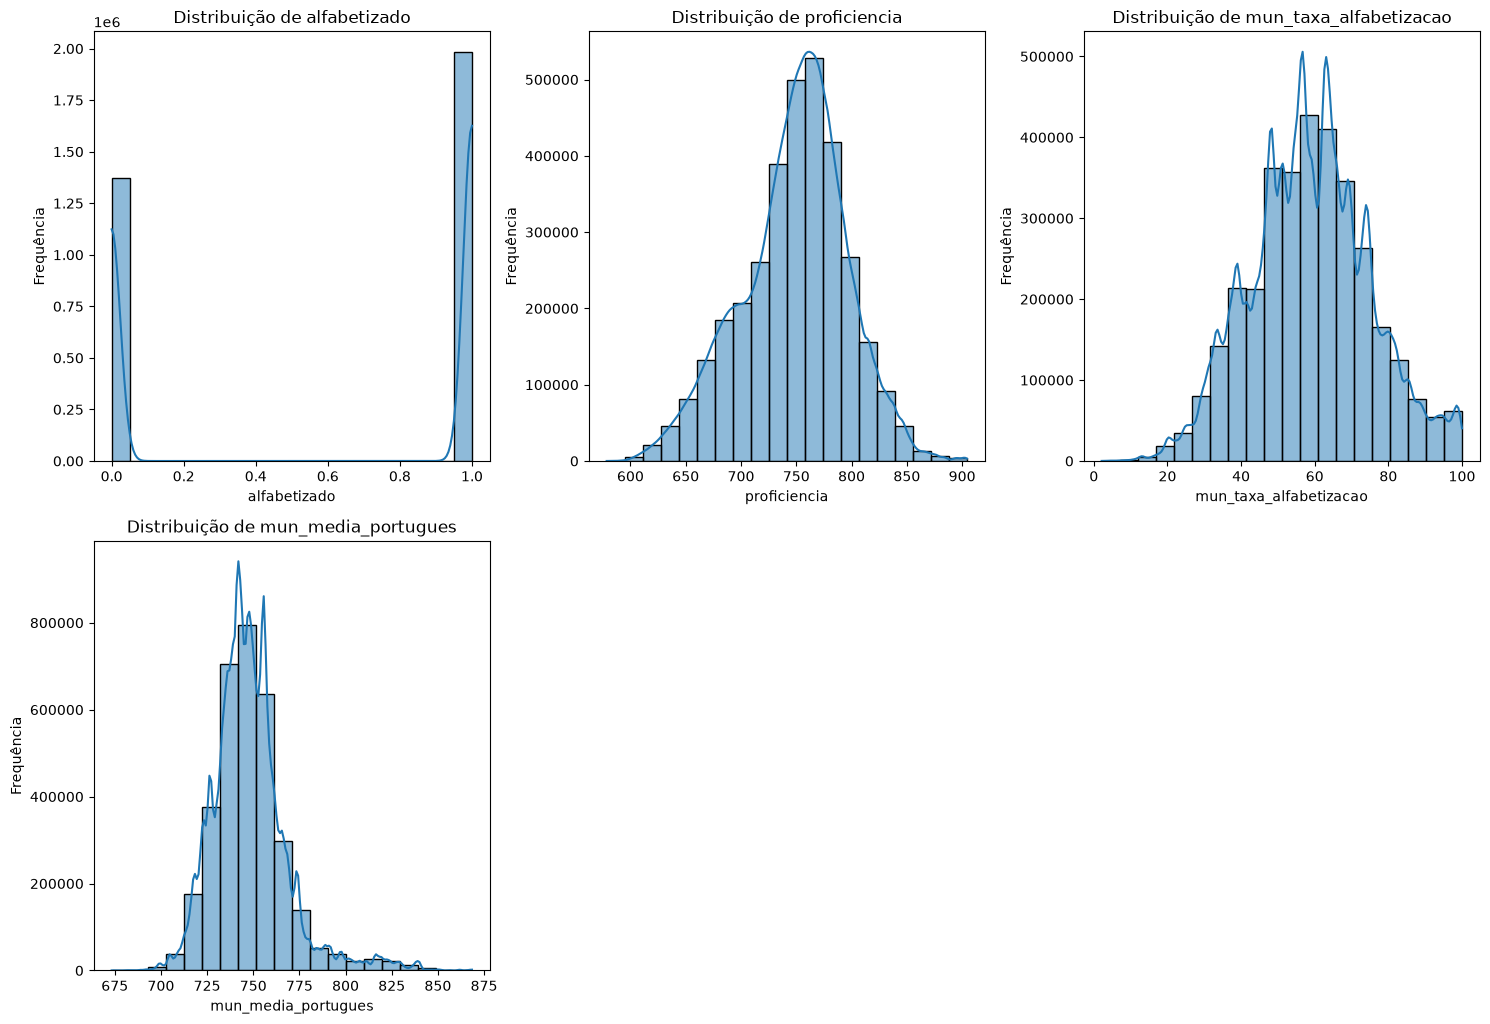

In [21]:
num_cols = len(df_dist.columns)
num_rows = (num_cols + 2) // 2 # Adjust rows based on 3 columns per row

plt.figure(figsize=(15, num_rows * 5))

for i, column in enumerate(df_dist.columns):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(df_dist[column], bins=20, kde=True)
    plt.title(f'Distribuição de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

              contagem  percentual
alfabetizado                      
1              1984530       59.14
0              1371292       40.86


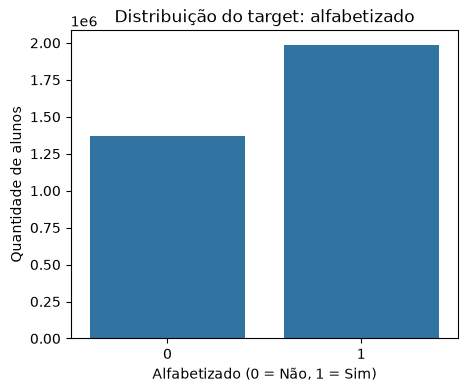

In [35]:
# analisando balanceamento da target "alfabetizado"
contagem = df["alfabetizado"].value_counts()
percentual = df["alfabetizado"].value_counts(normalize=True) * 100

resumo_target = pd.DataFrame({"contagem": contagem, "percentual": percentual.round(2)})
print(resumo_target)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="alfabetizado")
plt.title("Distribuição do target: alfabetizado")
plt.xlabel("Alfabetizado (0 = Não, 1 = Sim)")
plt.ylabel("Quantidade de alunos")
plt.show()

In [37]:
for col in ["ano", "rede"]:
    print(f"\n--- alfabetizado (%) por {col} ---")
    print((df.groupby(col)["alfabetizado"].mean() * 100).round(2))


--- alfabetizado (%) por ano ---
ano
2023    58.38
2024    59.75
Name: alfabetizado, dtype: float64

--- alfabetizado (%) por rede ---
rede
Estadual     62.09
Municipal    58.77
Name: alfabetizado, dtype: float64


In [32]:
out_lista_variaveis =  [
'proficiencia',
'mun_taxa_alfabetizacao',
'mun_media_portugues',
'alfabetizado'
]

df_dist_alf = df[out_lista_variaveis]

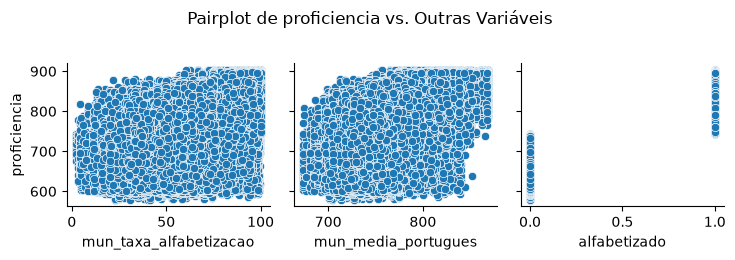

In [34]:
# comparando com target
sns.pairplot(df_dist_alf, y_vars=['proficiencia'], x_vars=df_dist_alf.drop('proficiencia', axis=1), kind='scatter')
plt.suptitle(f'Pairplot de proficiencia vs. Outras Variáveis', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# incluir mais variaveis, provenientes da camada gold....